# PRCP-1025-FlightPricePrediction

# Task 1:- Prepare a complete data analysis report on the given data.

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

I0000 00:00:1785583028.718255     732 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785583028.719555     732 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785583028.914093     732 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785583032.046716     732 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785583032.047383     732 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# 2. Load the Dataset

In [2]:
df = pd.read_csv("Flight_Fare.csv")

# 3. Basic Checks

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
df.sample(5, random_state=1)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
7931,SpiceJet,15/03/2019,Mumbai,Hyderabad,BOM → HYD,22:45,00:10 16 Mar,1h 25m,non-stop,No info,2753
5468,SpiceJet,15/03/2019,Banglore,New Delhi,BLR → DEL,09:35,12:30,2h 55m,non-stop,No info,6309
8618,Jet Airways,9/06/2019,Kolkata,Banglore,CCU → BOM → BLR,16:30,04:40 10 Jun,12h 10m,1 stop,No info,13731
3836,Jet Airways,18/03/2019,Banglore,New Delhi,BLR → BOM → DEL,22:50,09:00 16 Mar,10h 10m,1 stop,No info,13555
7771,Jet Airways,21/05/2019,Kolkata,Banglore,CCU → BOM → BLR,21:10,18:15 22 May,21h 5m,1 stop,In-flight meal not included,10844


In [6]:
df.shape

(10683, 11)

In [7]:
df.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

In [8]:
df.nunique()

Airline              12
Date_of_Journey      44
Source                5
Destination           6
Route               128
Dep_Time            222
Arrival_Time       1343
Duration            368
Total_Stops           5
Additional_Info      10
Price              1870
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [10]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [11]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [12]:
df.duplicated().sum()

np.int64(220)

In [13]:
df["Airline"].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

# 4. Handling Missing Values
The dataset has one missing value each in `Route` and `Total_Stops` (they belong to the same row). Since it is a single row out of 10,683, it is safely dropped rather than imputed.

In [14]:
df.dropna(subset=["Total_Stops"], inplace=True)

In [15]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

# 5. Exploratory Data Analysis (EDA)

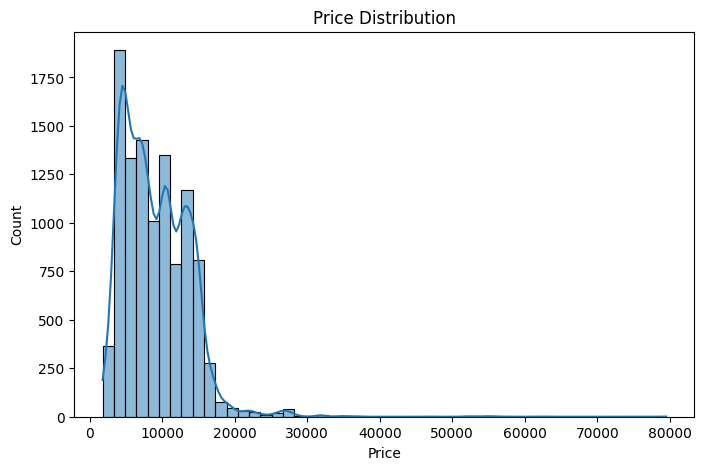

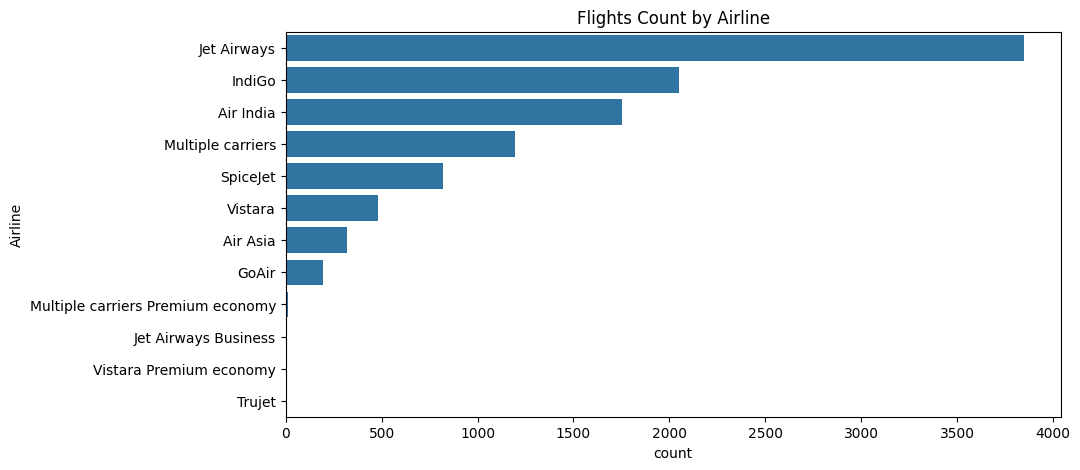

In [16]:
# Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

# Airline Distribution
plt.figure(figsize=(10,5))
sns.countplot(y=df["Airline"], order=df["Airline"].value_counts().index)
plt.title("Flights Count by Airline")
plt.show()

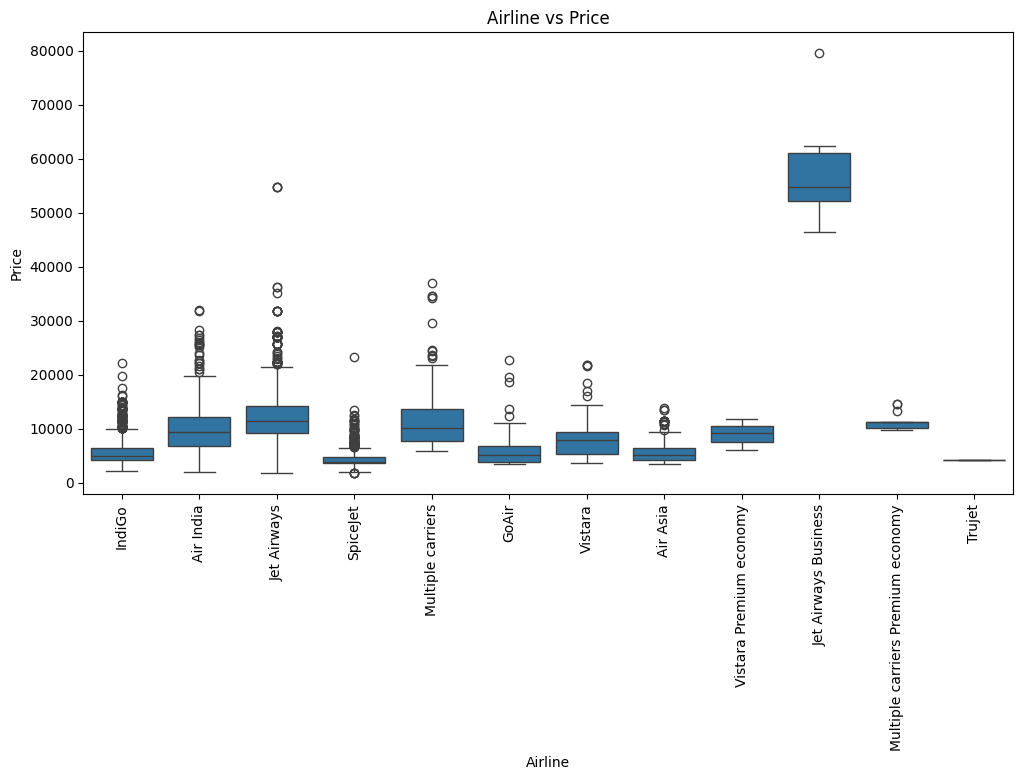

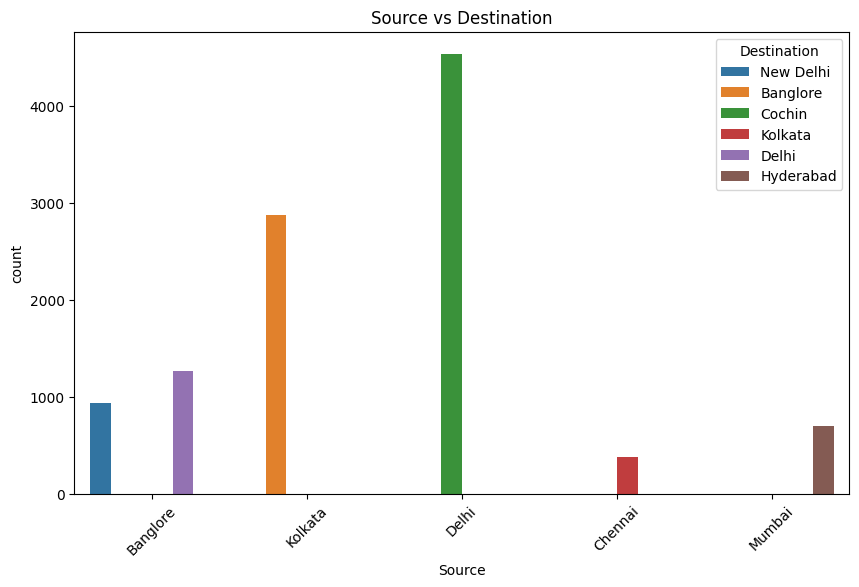

In [17]:
# Airline vs Price
plt.figure(figsize=(12,6))
sns.boxplot(x="Airline", y="Price", data=df)
plt.xticks(rotation=90)
plt.title("Airline vs Price")
plt.show()

# Source vs Destination
plt.figure(figsize=(10,6))
sns.countplot(x="Source", hue="Destination", data=df)
plt.title("Source vs Destination")
plt.xticks(rotation=45)
plt.show()

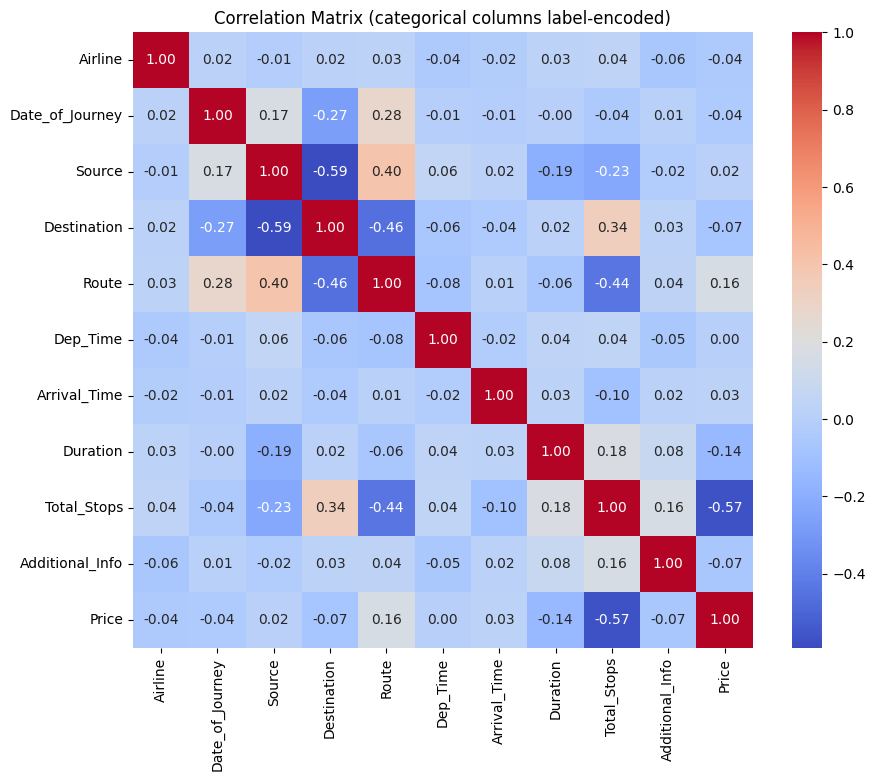

In [18]:
# Encode categorical columns temporarily (copy of df) just for a correlation view
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=["object", "str"]).columns:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (categorical columns label-encoded)")
plt.show()

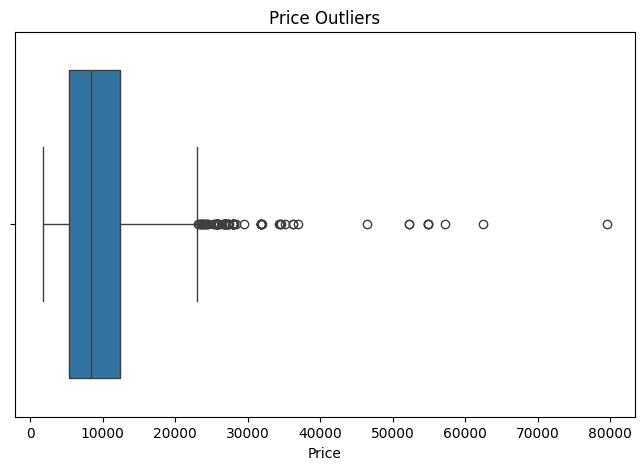

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Price"])
plt.title("Price Outliers")
plt.show()

### EDA Insights
1. The dataset contains flight fare details including airline, route, duration, and price.
2. Price distribution shows right skewness (a small number of very expensive tickets pull the mean above the median).
3. Some airlines (e.g. Jet Airways) charge noticeably higher average fares than budget carriers (e.g. SpiceJet, IndiGo).
4. Duration and number of stops influence price - non-stop flights tend to be cheaper than multi-stop itineraries.
5. `Date_of_Journey`, `Dep_Time`, `Arrival_Time`, and `Duration` are text/object fields and need feature engineering before they are usable by any ML model.

# 6. Feature Engineering
The raw `Date_of_Journey`, `Dep_Time`, `Arrival_Time`, and `Duration` columns are text and cannot be fed to a model directly. Each one is converted into numeric features below, and `Total_Stops` (an ordinal field) is mapped to integers instead of being one-hot encoded.

In [20]:
# Date_of_Journey -> day, month
df["Journey_day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day
df["Journey_month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month
df.drop("Date_of_Journey", axis=1, inplace=True)

In [21]:
# Dep_Time -> hour, minute
df["Dep_hour"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.hour
df["Dep_min"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.minute
df.drop("Dep_Time", axis=1, inplace=True)

In [22]:
# Arrival_Time sometimes has a trailing date fragment (e.g. "01:10 22 Mar") -> keep only the time part
df["Arrival_Time"] = df["Arrival_Time"].apply(lambda x: x.split(" ")[0])
df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"], format="%H:%M").dt.hour
df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"], format="%H:%M").dt.minute
df.drop("Arrival_Time", axis=1, inplace=True)

In [23]:
# Duration ("2h 50m", "19h", "45m") -> total minutes
def duration_to_minutes(x):
    x = x.strip()
    hours, minutes = 0, 0
    if "h" in x:
        hours = int(x.split("h")[0].strip())
        rem = x.split("h")[1].strip()
        if "m" in rem:
            minutes = int(rem.replace("m", "").strip())
    elif "m" in x:
        minutes = int(x.replace("m", "").strip())
    return hours * 60 + minutes

df["Duration_mins"] = df["Duration"].apply(duration_to_minutes)
df.drop("Duration", axis=1, inplace=True)

In [24]:
# Total_Stops is ordinal - map to integers instead of one-hot encoding
stops_map = {"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}
df["Total_Stops"] = df["Total_Stops"].map(stops_map)

# Normalise inconsistent casing found in Additional_Info
df["Additional_Info"] = df["Additional_Info"].replace("No Info", "No info")

# Route is redundant once Total_Stops is numeric and has very high cardinality (128 unique values) - dropped
df.drop("Route", axis=1, inplace=True)

df.isnull().sum()

Airline            0
Source             0
Destination        0
Total_Stops        0
Additional_Info    0
Price              0
Journey_day        0
Journey_month      0
Dep_hour           0
Dep_min            0
Arrival_hour       0
Arrival_min        0
Duration_mins      0
dtype: int64

In [25]:
df.dtypes

Airline              str
Source               str
Destination          str
Total_Stops        int64
Additional_Info      str
Price              int64
Journey_day        int32
Journey_month      int32
Dep_hour           int32
Dep_min            int32
Arrival_hour       int32
Arrival_min        int32
Duration_mins      int64
dtype: object

# 7. Encoding Remaining Categorical Features

In [26]:
categorical_cols = df.select_dtypes(include=["object", "str"]).columns
print(categorical_cols)

Index(['Airline', 'Source', 'Destination', 'Additional_Info'], dtype='str')


In [27]:
df = pd.get_dummies(df, columns=list(categorical_cols), drop_first=True)
df.shape

(10682, 37)

# 8. Train-Test Split

In [28]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((8545, 36), (2137, 36))

# 9. Model Building & Evaluation

### 9.1 Linear Regression (baseline)

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

RMSE: 2588.5090655115982
R2 Score: 0.6892513830080536


### 9.2 Decision Tree Regressor

In [30]:
dt = DecisionTreeRegressor(
    max_depth=15,
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

RMSE: 1481.1979507214146
R2 Score: 0.89824962256671


### 9.3 Random Forest Regressor

In [31]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

RMSE: 1429.3241480969557
R2 Score: 0.9052517306503925


### 9.4 XGBoost Regressor

In [32]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

RMSE: 1434.4612664690533
R2 Score: 0.9045694470405579


### 9.5 Artificial Neural Network (ANN)

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ann = Sequential()
ann.add(Input(shape=(X_train_scaled.shape[1],)))
ann.add(Dense(128, activation="relu"))
ann.add(Dense(64, activation="relu"))
ann.add(Dense(32, activation="relu"))
ann.add(Dense(1))

ann.compile(optimizer="adam", loss="mse")
ann.fit(X_train_scaled, y_train, epochs=5, batch_size=32, verbose=1)

y_pred_ann = ann.predict(X_test_scaled).flatten()

rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_ann = r2_score(y_test, y_pred_ann)
print("RMSE:", rmse_ann)
print("R2 Score:", r2_ann)

Epoch 1/5


E0000 00:00:1785583046.325692     732 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  1/268 ━━━━━━━━━━━━━━━━━━━━ 6:14 1s/step - loss: 89999736.0000

 25/268 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 98654536.0000 

 52/268 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 102846032.0000

...

 1/67 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step

46/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


RMSE: 2396.4938973425324
R2 Score: 0.7336440086364746


### 9.6 K-Nearest Neighbors (KNN) Regressor

In [34]:
scaler_knn = StandardScaler()
X_train_scaled_knn = scaler_knn.fit_transform(X_train)
X_test_scaled_knn = scaler_knn.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled_knn, y_train)

y_pred_knn = knn.predict(X_test_scaled_knn)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)

RMSE: 1816.1276379338533
R2 Score: 0.8470313059348055


# 10. Hyperparameter Tuning
The Decision Tree and XGBoost models are re-tuned with `GridSearchCV`, and RMSE/R2 are recomputed on the predictions from the *tuned* estimators.

### 10.1 Tuned Decision Tree

In [35]:
param_grid_dt = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt_tuned))
r2_dt = r2_score(y_test, y_pred_dt_tuned)

print("Best DT Parameters:", grid_dt.best_params_)
print("\nTuned DecisionTreeRegressor Performance:")
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Best DT Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}

Tuned DecisionTreeRegressor Performance:
RMSE: 1484.7121519479858
R2 Score: 0.89776623616033


### 10.2 Tuned XGBoost

In [36]:
param_grid_xgb = {
    "n_estimators": [300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(objective="reg:squarederror", random_state=42),
    param_grid=param_grid_xgb,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_

print("Best Parameters Found:")
print(grid_search.best_params_)

y_pred_xgb_tuned = best_xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb = r2_score(y_test, y_pred_xgb_tuned)

print("\nTuned XGBoost Performance:")
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


Best Parameters Found:
{'learning_rate': 0.03, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.8}

Tuned XGBoost Performance:
RMSE: 1400.395569116098
R2 Score: 0.9090481996536255


# 11. Model Comparison

In [37]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree (Tuned)",
        "Random Forest",
        "XGBoost (Tuned)",
        "ANN",
        "KNN"
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_xgb,
        rmse_ann,
        rmse_knn
    ],
    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_xgb,
        r2_ann,
        r2_knn
    ]
})

print("MODEL COMPARISON")
results.sort_values("RMSE").reset_index(drop=True)

MODEL COMPARISON


,Model,RMSE,R2 Score
0,XGBoost (Tuned),1400.395569,0.909048
1,Random Forest,1429.324148,0.905252
2,Decision Tree (Tuned),1484.712152,0.897766
3,KNN,1816.127638,0.847031
4,ANN,2396.493897,0.733644
5,Linear Regression,2588.509066,0.689251


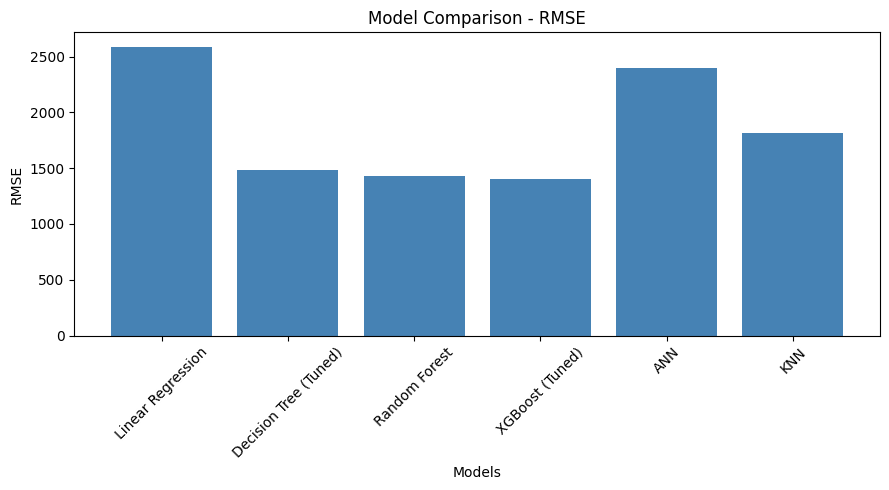

In [38]:
plt.figure(figsize=(9,5))
plt.bar(results["Model"], results["RMSE"], color="steelblue")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

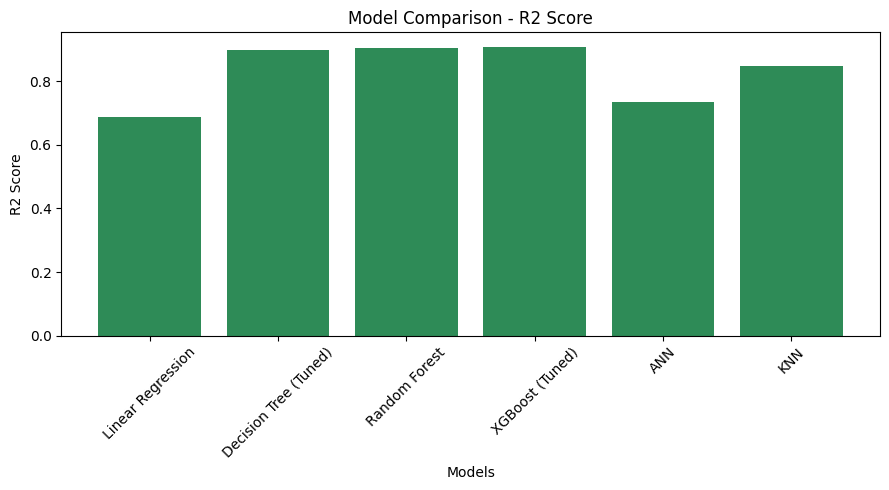

In [39]:
plt.figure(figsize=(9,5))
plt.bar(results["Model"], results["R2 Score"], color="seagreen")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison - R2 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 12. EDA & Business Impact Report

### Key Observations
1. **Price Distribution:** Ticket prices are right-skewed, with most fares concentrated in the lower-to-mid range and a long tail of premium/last-minute fares.
2. **Airline Influence:** Premium airlines (e.g. Jet Airways) charge significantly higher fares. Budget airlines (e.g. IndiGo, SpiceJet) offer more competitive pricing.
3. **Seasonal Effect:** Ticket prices vary by month of travel, reflecting demand fluctuations across the travel season covered by the data.
4. **Duration Effect:** Longer travel duration (more stops, longer routes) often correlates with higher ticket prices.
5. **Time of Departure:** Early morning and late-night flights are comparatively cheaper; peak-hour flights are more expensive.

### Business Impact
**For Customers:** Enables better financial planning, helps identify cheaper travel alternatives, and encourages flexible travel timing.

**For Airlines:** Assists in dynamic pricing strategy evaluation, improves revenue management, and supports demand forecasting.

**Challenges Faced:** Handling a skewed price distribution, managing categorical variables with many levels (esp. Route, Arrival_Time before feature engineering), and preventing overfitting in complex models while selecting optimal hyperparameters.

# Model Comparison Report

**Summary of Evaluated Models**

**1. Linear Regression:** Used as a baseline model. It showed the highest prediction error since it cannot capture the non-linear relationships present in flight pricing data.

**2. XGBoost Regressor (Tuned):** Achieved the lowest RMSE and highest R² score among all models after hyperparameter tuning, showing excellent generalization and the best overall performance.

**3. Random Forest Regressor:** Delivered strong, consistent performance very close to XGBoost, with good stability from ensembling many trees.

**4. Decision Tree Regressor (Tuned):** Handled non-linear feature interactions well; tuning controlled its tendency to overfit compared to an unconstrained tree.

**5. K-Nearest Neighbors (KNN) Regressor:** Captured local patterns in the data; performance is sensitive to feature scaling and the choice of K.

**6. Artificial Neural Network (ANN):** Captured complex pricing patterns reasonably well but needed more epochs/tuning than the tree-based models to fully match their accuracy in this run.

# Report on Challenges Faced

During the development of the Flight Fare Prediction project, several challenges were encountered in both the data analysis and model building stages. The key challenges and solutions applied are summarized below:

**1. Data Cleaning & Missing Values**
- *Challenge:* The dataset contained a missing value in `Route` and `Total_Stops` (same row).
- *Technique Used:* Dropped the single affected row since it was negligible relative to the dataset size.
- *Reason:* Avoids introducing bias from imputing a categorical value with very few options.

**2. Date & Time Feature Engineering**
- *Challenge:* `Date_of_Journey`, `Dep_Time`, and `Arrival_Time` were in string format and not directly usable for modeling. `Arrival_Time` inconsistently included a trailing date fragment for overnight flights.
- *Technique Used:* Extracted day, month, hour, and minute from the datetime columns into separate numeric features; parsed only the time portion of `Arrival_Time`.
- *Reason:* Machine learning models require numerical input, and extracting meaningful time-based features improved model performance.

**3. Categorical Variable Encoding**
- *Challenge:* Features like `Airline`, `Source`, `Destination`, and `Additional_Info` were categorical (nominal), while `Total_Stops` was ordinal.
- *Technique Used:* Used one-hot encoding for nominal features and mapped `Total_Stops` to integers instead of one-hot encoding it.
- *Reason:* Encoding transformed categorical data into a machine-readable numerical format without introducing artificial ordinal bias for nominal fields, and preserved the true ordinal structure of `Total_Stops`.

**4. High Dimensionality After Encoding**
- *Challenge:* `Route` had 128 unique values and, before feature engineering, `Arrival_Time` had 1,343 unique values — one-hot encoding either directly would have produced an unmanageable number of sparse columns.
- *Technique Used:* Dropped `Route` (redundant with the numeric `Total_Stops`) and converted time columns into a handful of numeric features instead of one-hot encoding them.
- *Reason:* Reduced dimensionality dramatically, improving model efficiency and reducing overfitting risk.

**5. Model Selection & Performance Variation**
- *Challenge:* Different models showed large performance differences (Linear Regression vs ANN vs XGBoost).
- *Technique Used:* Compared Linear Regression, Decision Tree, Random Forest, XGBoost, ANN, and KNN, evaluated using RMSE and R² Score.
- *Reason:* Model comparison ensured selection of the best-performing algorithm for production.

**6. Overfitting in Complex Models**
- *Challenge:* The unconstrained Decision Tree showed a tendency to overfit.
- *Technique Used:* Applied hyperparameter tuning (`GridSearchCV`) with cross-validation for the Decision Tree and XGBoost models.
- *Reason:* Tuning improved generalization and reduced the training-testing performance gap.

**7. Computational Constraints**
- *Challenge:* `GridSearchCV` over ensemble/boosting models and the ANN required more training time and computation than the simpler models.
- *Technique Used:* Used `n_jobs=-1` for parallel cross-validation and kept the ANN's epoch count modest.
- *Reason:* Improved training efficiency without significantly affecting accuracy.

**Overall Learning:**
- Proper feature engineering significantly improves model accuracy.
- Ensemble/boosting models outperform basic regression on this complex, mixed-type dataset.
- Hyperparameter tuning is critical for production-ready models.
- Model comparison helps in selecting the most reliable algorithm.

# Summary

This project focused on building a predictive machine learning model to estimate flight ticket prices and help customers make informed travel decisions. The primary objective was to analyze historical flight data, identify key pricing factors, and develop a high-accuracy regression model suitable for real-world deployment.

The project began with comprehensive data preprocessing, including handling missing values, transforming date and time features, encoding categorical variables, and performing exploratory data analysis. Feature engineering played a crucial role in improving prediction performance, particularly by extracting meaningful components such as journey day, month, departure hour, arrival hour, and duration in minutes.

Multiple machine learning models were implemented and evaluated, including Linear Regression, KNN, Random Forest, XGBoost, Decision Tree, and Artificial Neural Networks (ANN). Model performance was assessed using RMSE and R² score to ensure both accuracy and reliability.

Through systematic comparison and hyperparameter tuning, the tuned XGBoost model demonstrated the best overall performance, closely followed by Random Forest, while cross-validation techniques helped reduce overfitting and improve generalization capability.